### linear regression  practice implement

In [ ]:
import pandas as pd

In [ ]:
from sklearn.datasets import fetch_california_housing

In [ ]:
from sklearn.datasets import fetch_openml

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [ ]:
boston = fetch_openml(name='boston', version=1) 

In [ ]:
boston

In [ ]:
df=boston

In [ ]:
df

In [ ]:
dataset=pd.DataFrame(df.data)

In [ ]:
dataset

In [ ]:
dataset.columns=df.feature_names

In [ ]:
dataset.head()

In [ ]:
x=dataset
y=df.target

In [ ]:
y

In [ ]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(
   x, y, test_size=0.30, random_state=42)

In [ ]:
X_train

In [ ]:
y_train

In [ ]:
X_test

### standarization the dataset

In [ ]:
from sklearn.preprocessing import StandardScaler
scaler=StandardScaler()

In [ ]:
X_train=scaler.fit_transform(X_train)

In [ ]:
X_test=scaler.transform(X_test)

In [ ]:
##to inverse transform
#scaler.inverse_transform(x_train)

In [ ]:
from sklearn.linear_model import LinearRegression
#cross validation
from sklearn.model_selection import cross_val_score
from sklearn.metrics import mean_squared_error

In [ ]:
regression=LinearRegression()
regression.fit(X_train,y_train)

In [ ]:
mse=cross_val_score(regression,X_train,y_train,scoring='neg_mean_squared_error',cv=10)

In [ ]:
np.mean(mse)

In [ ]:
##PREDICTION OF TEST DATA
reg_pred=regression.predict(X_test)

In [ ]:
reg_pred

In [ ]:
#compare predicted value with truth value(y_test)


In [ ]:
import seaborn as sns
sns.displot(reg_pred-y_test,kind='kde')

In [ ]:
from sklearn.metrics import r2_score

In [ ]:
score=r2_score(reg_pred,y_test)

In [ ]:
score

### RIDGE REGRESSION


In [ ]:
from sklearn.linear_model import Ridge
from sklearn.model_selection import GridSearchCV

In [ ]:
ridge_reg=Ridge()

In [ ]:
ridge_reg

In [45]:
parameters={'alpha':[1,2,5,10,20,30,40,50,60,70,80,90]}
ridgeCV=GridSearchCV(ridge_reg,parameters,scoring='neg_mean_squared_error',cv=5)
ridgeCV.fit(X_train,y_train)


GridSearchCV(cv=5, estimator=Ridge(),
             param_grid={'alpha': [1, 2, 5, 10, 20, 30, 40, 50, 60, 70, 80,
                                   90]},
             scoring='neg_mean_squared_error')

In [46]:
print(ridgeCV.best_params_)

{'alpha': 10}


In [47]:
print(ridgeCV.best_score_)

-25.80722882229147


### predict


In [49]:
ridge_pred=ridgeCV.predict(X_test)

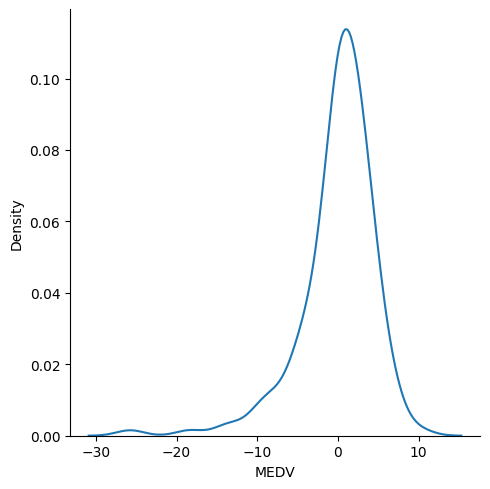

In [50]:
import seaborn as sns
sns.displot(ridge_pred-y_test,kind='kde')

In [51]:
score=r2_score(ridge_pred,y_test)

In [52]:
score

0.6468557055633651

### LASSO REGRESSION

In [53]:
from sklearn.linear_model import Lasso

In [54]:
lasso=Lasso()

In [55]:
parameters={'alpha':[1,2,5,10,20,30,40,50,60,70,80,90]}
lassoCV=GridSearchCV(lasso,parameters,scoring='neg_mean_squared_error',cv=5)
lassoCV.fit(X_train,y_train)

GridSearchCV(cv=5, estimator=Lasso(),
             param_grid={'alpha': [1, 2, 5, 10, 20, 30, 40, 50, 60, 70, 80,
                                   90]},
             scoring='neg_mean_squared_error')

In [56]:
print(lassoCV.best_params_)
print(lassoCV.best_score_)


{'alpha': 1}
-31.153603752119004


In [57]:
lasso_pred=lassoCV.predict(X_test)

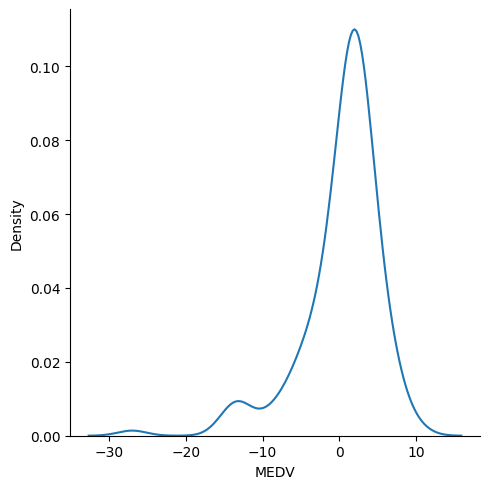

In [58]:
import seaborn as sns
sns.displot(lasso_pred-y_test,kind='kde')